# Fine-tune Dataset Preparation
Fixes three issues in the exported Roboflow dataset before merging with the original training data:
1. Class name mismatch (`plastic_bottle` → `Plastic bottle`, `tin_can` → `Aluminum can`)
2. No train/valid split (splits 93 images 80/20)
3. Mixed resolutions (resizes 4096×3072 mobile images to 640×640)

**Run this AFTER uploading your zip to Google Drive.**

## Step 1 — Mount Drive and extract dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf /content/custom_processed/ /content/custom_raw/

In [ ]:
import zipfile
import os

# Path to your uploaded zip on Drive — update if needed
ZIP_PATH = '/content/drive/MyDrive/trash_detection/tin_plastic_dataset_yolov8.zip'
EXTRACT_PATH = '/content/custom_raw'

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_PATH)

print("Extracted to:", EXTRACT_PATH)
print("Contents:", os.listdir(EXTRACT_PATH))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/trash_detection/tin_plastic_dataset_yolov8.zip'

In [ ]:
EXTRACT_PATH = '/content/drive/MyDrive/trash_detection/tin_plastic_dataset_yolov8_3'
# /content/drive/MyDrive/trash_detection/tin_plastic_dataset_yolov8

In [ ]:
print(EXTRACT_PATH)

/content/drive/MyDrive/trash_detection/tin_plastic_dataset_yolov8_2


## Step 2 — Inspect what we have

In [ ]:
import glob
from PIL import Image

train_imgs = glob.glob(f'{EXTRACT_PATH}/train/images/*')
train_lbls = glob.glob(f'{EXTRACT_PATH}/train/labels/*.txt')

print(f"Train images: {len(train_imgs)}")
print(f"Train labels: {len(train_lbls)}")

# Check resolution distribution
sizes = {}
for img_path in train_imgs:
    img = Image.open(img_path)
    size = img.size
    sizes[size] = sizes.get(size, 0) + 1

print("\nResolution distribution:")
for size, count in sorted(sizes.items()):
    print(f"  {size[0]}x{size[1]}: {count} images")

# Check class distribution
class_counts = {0: 0, 1: 0}
for lbl in train_lbls:
    with open(lbl) as f:
        for line in f:
            cls = int(line.strip().split()[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1

print("\nClass distribution (0=plastic_bottle, 1=tin_can):")
print(f"  Class 0: {class_counts[0]} instances")
print(f"  Class 1: {class_counts[1]} instances")

Train images: 606
Train labels: 614

Resolution distribution:
  640x640: 606 images

Class distribution (0=plastic_bottle, 1=tin_can):
  Class 0: 797 instances
  Class 1: 692 instances


## Step 3 — Resize mobile images to 640×640

In [ ]:
import shutil
from pathlib import Path

PROCESSED_PATH = '/content/custom_processed'
os.makedirs(f'{PROCESSED_PATH}/all/images', exist_ok=True)
os.makedirs(f'{PROCESSED_PATH}/all/labels', exist_ok=True)

TARGET_SIZE = (640, 640)
resized = 0
kept = 0

for img_path in train_imgs:
    stem = Path(img_path).stem
    ext = Path(img_path).suffix
    lbl_path = f'{EXTRACT_PATH}/train/labels/{stem}.txt'

    if not os.path.exists(lbl_path):
        print(f"WARNING: No label for {stem}, skipping")
        continue

    img = Image.open(img_path).convert('RGB')
    orig_w, orig_h = img.size  # capture BEFORE any resizing

    if (orig_w, orig_h) != TARGET_SIZE:
        # Calculate scale and padding BEFORE resizing
        scale = min(TARGET_SIZE[0] / orig_w, TARGET_SIZE[1] / orig_h)
        new_w = int(orig_w * scale)
        new_h = int(orig_h * scale)
        pad_x = (TARGET_SIZE[0] - new_w) / 2
        pad_y = (TARGET_SIZE[1] - new_h) / 2

        # Resize then paste onto canvas
        img = img.resize((new_w, new_h), Image.LANCZOS)
        canvas = Image.new('RGB', TARGET_SIZE, (114, 114, 114))
        canvas.paste(img, (int(pad_x), int(pad_y)))

        # Adjust YOLO labels using correct scale and padding
        new_labels = []
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls = int(parts[0])
                cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])

                # Transform: scale coords then add padding offset, normalize to target size
                new_cx = (cx * orig_w * scale + pad_x) / TARGET_SIZE[0]
                new_cy = (cy * orig_h * scale + pad_y) / TARGET_SIZE[1]
                new_bw = (bw * orig_w * scale) / TARGET_SIZE[0]
                new_bh = (bh * orig_h * scale) / TARGET_SIZE[1]
                new_labels.append(f"{cls} {new_cx:.6f} {new_cy:.6f} {new_bw:.6f} {new_bh:.6f}")

        out_img = f'{PROCESSED_PATH}/all/images/{stem}.jpg'
        canvas.save(out_img, 'JPEG', quality=95)
        with open(f'{PROCESSED_PATH}/all/labels/{stem}.txt', 'w') as f:
            f.write('\n'.join(new_labels))
        resized += 1
    else:
        shutil.copy(img_path, f'{PROCESSED_PATH}/all/images/{stem}{ext}')
        shutil.copy(lbl_path, f'{PROCESSED_PATH}/all/labels/{stem}.txt')
        kept += 1

print(f"Resized: {resized} | Kept: {kept} | Total: {resized + kept}")

Resized: 0 | Kept: 168 | Total: 168


## Step 4 — Train/valid split (80/20)

In [ ]:
import random

random.seed(42)  # Reproducible split

all_imgs = glob.glob(f'{PROCESSED_PATH}/all/images/*')
random.shuffle(all_imgs)

split_idx = int(len(all_imgs) * 0.8)
train_set = all_imgs[:split_idx]
valid_set = all_imgs[split_idx:]

print(f"Train: {len(train_set)} images")
print(f"Valid: {len(valid_set)} images")

for split, files in [('train', train_set), ('valid', valid_set)]:
    os.makedirs(f'{PROCESSED_PATH}/{split}/images', exist_ok=True)
    os.makedirs(f'{PROCESSED_PATH}/{split}/labels', exist_ok=True)
    for img_path in files:
        stem = Path(img_path).stem
        ext = Path(img_path).suffix
        lbl_path = f'{PROCESSED_PATH}/all/labels/{stem}.txt'
        shutil.copy(img_path, f'{PROCESSED_PATH}/{split}/images/{stem}{ext}')
        if os.path.exists(lbl_path):
            shutil.copy(lbl_path, f'{PROCESSED_PATH}/{split}/labels/{stem}.txt')

print("Split complete.")

Train: 134 images
Valid: 34 images
Split complete.


## Step 5 — Write corrected data.yaml

Class names updated to match the original training dataset exactly.

In [ ]:
import yaml

# Class IDs stay the same (0 and 1), only names are corrected
# Original dataset: 0=Plastic bottle, 1=Aluminum can
# This dataset:     0=plastic_bottle, 1=tin_can
# IDs match, just fix the display names

data_yaml = {
    'train': f'{EXTRACT_PATH}/train/images',
    'val':   f'{EXTRACT_PATH}/valid/images',
    'nc': 2,
    'names': ['Plastic bottle', 'Aluminum can']
}

yaml_path = f'{EXTRACT_PATH}/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print("data.yaml written:")
print(yaml.dump(data_yaml))

data.yaml written:
names:
- Plastic bottle
- Aluminum can
nc: 2
train: /content/drive/MyDrive/trash_detection/tin_plastic_dataset_yolov8_3/train/images
val: /content/drive/MyDrive/trash_detection/tin_plastic_dataset_yolov8_3/valid/images



## Step 6 — Verify annotations visually

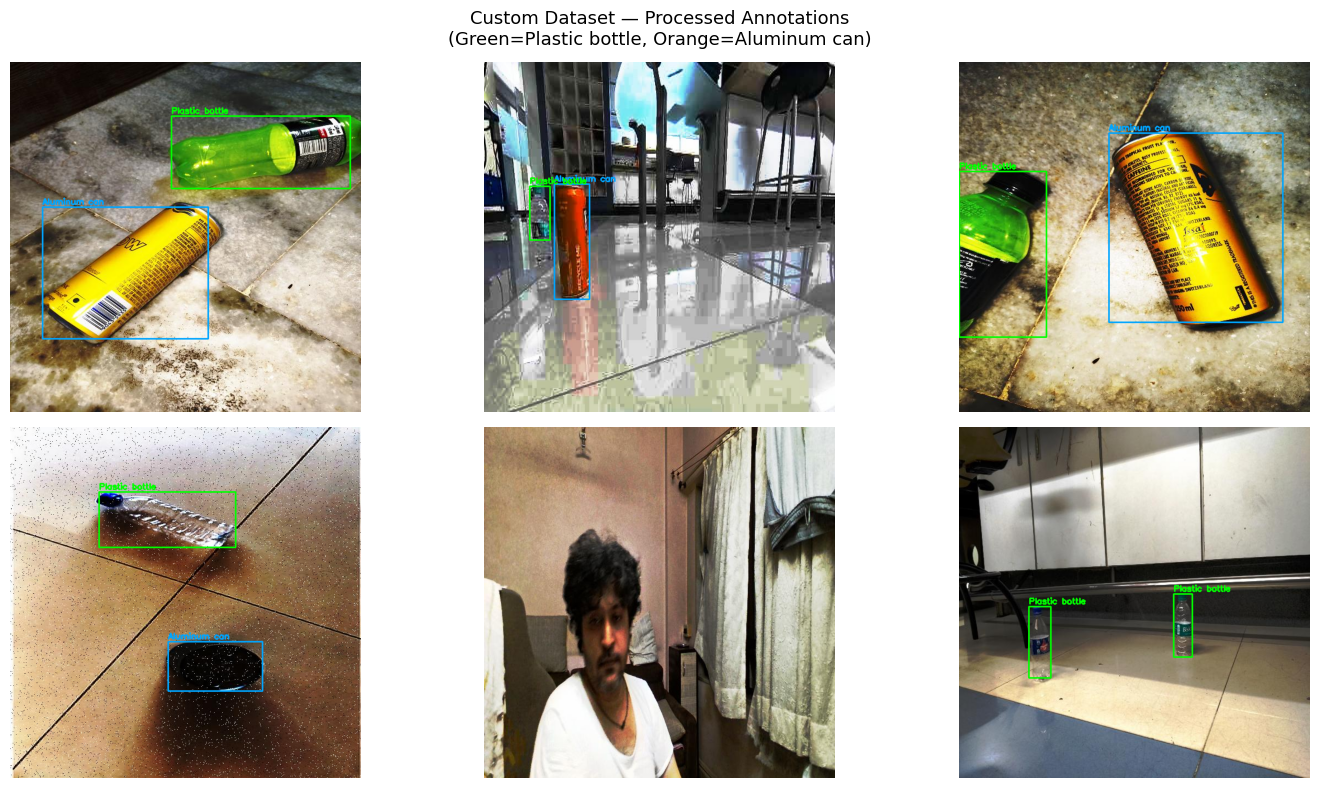

Preview saved to Drive.


In [ ]:
import cv2
import matplotlib.pyplot as plt
import random
import os
from pathlib import Path


CLASS_NAMES = ['Plastic bottle', 'Aluminum can']
COLOR_MAP = {0: (0, 255, 0), 1: (0, 165, 255)}

sample_imgs = random.sample(glob.glob(f'{EXTRACT_PATH}/train/images/*'), min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_imgs):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    stem = Path(img_path).stem
    lbl_path = f'{EXTRACT_PATH}/train/labels/{stem}.txt'

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                color = COLOR_MAP[cls]
                cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
                cv2.putText(img, CLASS_NAMES[cls], (x1, y1-5),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    ax.imshow(img)
    ax.axis('off')

plt.suptitle('Custom Dataset — Processed Annotations\n(Green=Plastic bottle, Orange=Aluminum can)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/trash_detection/custom_dataset_preview.png', dpi=150)
plt.show()
print("Preview saved to Drive.")

## Step 7 — Fine-tune from best.pt

In [ ]:
!pip install ultralytics --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load your best weights from Phase 1
BEST_PT = '/content/drive/MyDrive/trash_detection/recycle_detector_v2_best.pt'
model = YOLO(BEST_PT)

results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    lr0=0.0001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    mosaic=0.5,
    mixup=0.05,
    cls_pw=1.0,        # Changed from 1.5 — max allowed is 1.0 in this version
    patience=10,
    optimizer='AdamW',
    project='/content/drive/MyDrive/trash_detection/runs',
    name='recycle_v2',
    exist_ok=True,
    device=0,
    verbose=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=1.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/trash_detection/tin_plastic_dataset_yolov8_3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half

## Step 8 — Evaluate fine-tuned model

In [ ]:
best_v2 = YOLO('/content/drive/MyDrive/trash_detection/runs/recycle_v2/weights/best.pt')

metrics = best_v2.val(
    data=yaml_path,
    split='val',
    imgsz=640,
    conf=0.25,
    iou=0.6
)

print(f"\n=== Fine-tuned Model Results ===")
print(f"mAP@50:      {metrics.box.map50:.4f}")
print(f"mAP@50-95:   {metrics.box.map:.4f}")
print(f"Precision:   {metrics.box.mp:.4f}")
print(f"Recall:      {metrics.box.mr:.4f}")
print(f"\nPer-class mAP@50:")
CLASS_NAMES = ['Plastic bottle', 'Aluminum can']
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {metrics.box.ap50[i]:.4f}")

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 32.6±5.7 MB/s, size: 62.8 KB)
val: Scanning /content/drive/MyDrive/trash_detection/tin_plastic_dataset_yolov8_3/valid/labels.cache... 13 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13/13 5.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.3it/s 0.8s
                   all         13         26      0.967      0.953      0.955      0.714
        Plastic bottle         10         12          1      0.906      0.915       0.61
          Aluminum can         12         14      0.933          1      0.995      0.818
Speed: 0.9ms preprocess, 34.0ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val

=== Fine-tuned Model Results ===
mAP@50:      0.9550
mAP@5

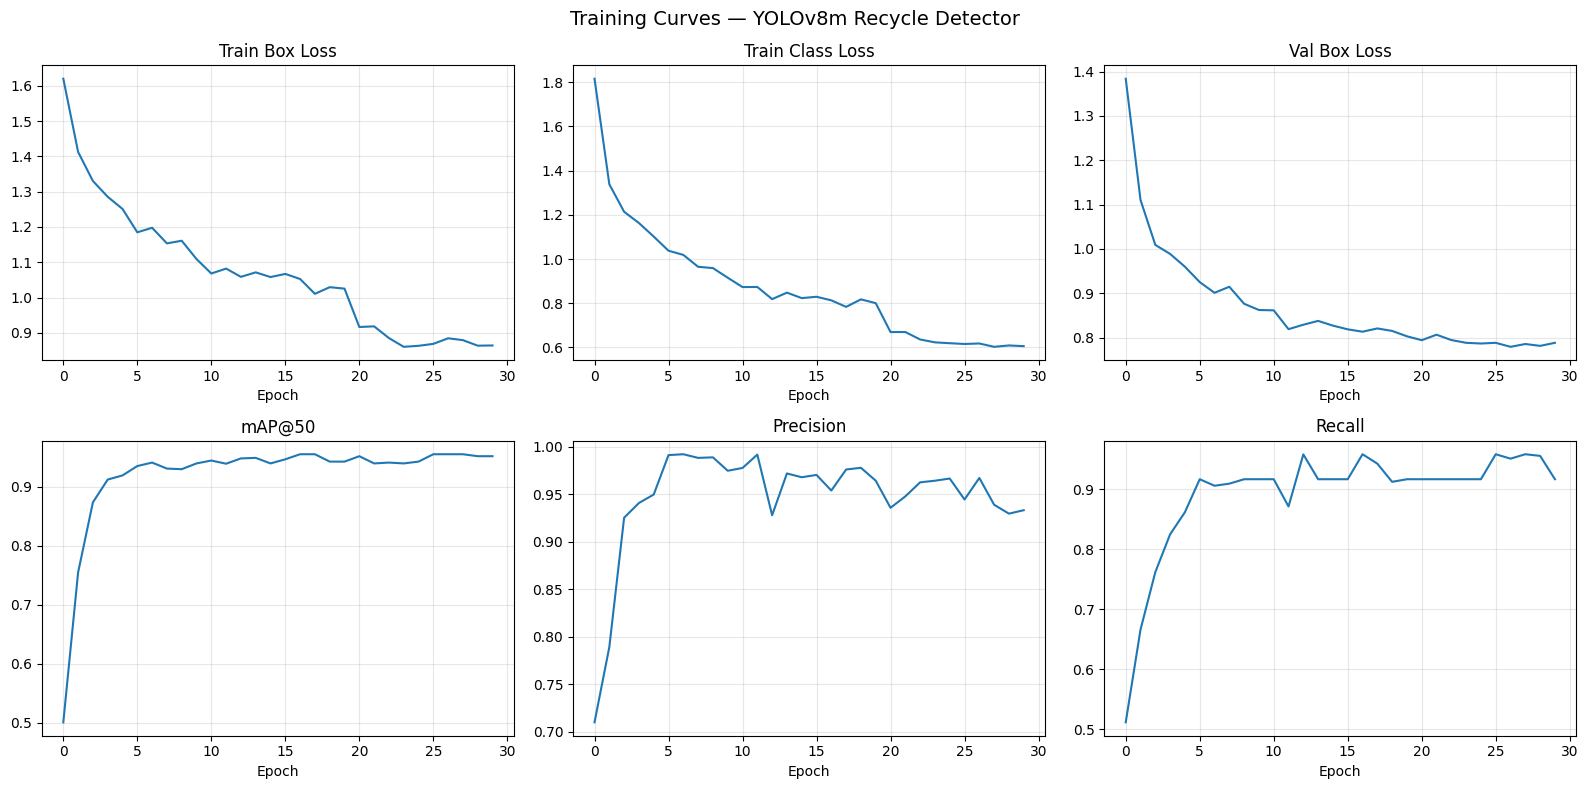

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = pd.read_csv('/content/drive/MyDrive/trash_detection/runs/recycle_v2/results.csv')
results_csv.columns = results_csv.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

plots = [
    ('train/box_loss',  'Train Box Loss',  axes[0][0]),
    ('train/cls_loss',  'Train Class Loss', axes[0][1]),
    ('val/box_loss',    'Val Box Loss',    axes[0][2]),
    ('metrics/mAP50(B)',   'mAP@50',          axes[1][0]),
    ('metrics/precision(B)', 'Precision',       axes[1][1]),
    ('metrics/recall(B)',    'Recall',          axes[1][2]),
]

for col, title, ax in plots:
    if col in results_csv.columns:
        ax.plot(results_csv[col])
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves — YOLOv8m Recycle Detector', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Step 9 — Download fine-tuned weights

In [2]:
import shutil
from google.colab import files

shutil.copy('/content/drive/MyDrive/trash_detection/runs/recycle_v2/weights/best.pt', 'recycle_detector_v6_best.pt')
files.download('recycle_detector_v6_best.pt')
print("Downloaded recycle_detector_v6_best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded recycle_detector_v6_best.pt
